In [72]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [73]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [74]:
urls =  [
    "https://python.langchain.com/docs/get_started/introduction/",
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/how_to/"]

In [75]:
docs = [WebBaseLoader(url).load() for url in urls]
print(docs)

[[Document(metadata={'source': 'https://python.langchain.com/docs/get_started/introduction/', 'title': 'Quickstart - Docs by LangChain', 'language': 'en'}, page_content='Quickstart - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationGet startedQuickstartDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIDeploy with LangSmithDeploymentObservabilityOn this pageRequirementsBuild a basic agentBuild a real-world agentGet startedQuickstartCopy pageCopy pageThis quickstart takes y

In [76]:
doc_list = [doc for sublist in docs for doc in sublist]

In [77]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
split_docs = text_splitter.split_documents(doc_list)
vectorestore = FAISS.from_documents(documents = split_docs,embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"))
retriever = vectorestore.as_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5953.19it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [78]:
msg = retriever.invoke("What is langchain")
msg[1].page_content

'See the Installation instructions and Quickstart guide to get started building your own agents and applications with LangChain.\nUse LangSmith to trace requests, debug agent behavior, and evaluate outputs. Set LANGSMITH_TRACING=true and your API key to get started.\n\u200b Core benefits'

In [79]:
# Retriever grader 

from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

from pydantic import BaseModel, Field

class grade(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score:str=Field(description="Documents are relevant to the question,'Yes' or 'No'")


llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)
llm = llm.with_structured_output(grade)


system = """You are a grader assessing relevance of a retrieved document to a user question.\n
            If the document contains Keyword(s) or semantic meaning related to the question, grade it as relevant.\n
            Give a binary score 'Yes' or 'No' score to indicate whether the document is relevant to the question."""

prompt_template = ChatPromptTemplate.from_messages([("system",system),("human","Retrieved document: \n\n {document}, User question: {question}")])

grade_chain = prompt_template | llm
question = "What is langchain?"
docs = retriever.invoke(question)
retrieved_docs = docs[1].page_content
response = grade_chain.invoke({"document":retrieved_docs,"question":question})
print(response)


binary_score='Yes'


In [80]:
# generate
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

prompt = hub.pull("rlm/rag-prompt")
llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)

def format_dcs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

chain = prompt | llm | StrOutputParser()

response = chain.invoke({"question":question,"context":docs})
print(response)

LangChain is an open-source framework with a prebuilt agent architecture and integrations for any model or tool. It allows users to build agents that adapt as fast as the ecosystem evolves. LangChain provides a flexible and adaptable framework for building agents and applications.


In [81]:
# Transform the query

llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)

# prompt
system = """You are a question rewriter that converts an input question to a better version that is optimized \n
            for a web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

updated_prompt = ChatPromptTemplate.from_messages([("system",system),("human","here is the initial question: \n\n {question} \n formulate an improved question.")])

updated_trandform_chain = updated_prompt | llm | StrOutputParser()
response = updated_trandform_chain.invoke({"question":question})
def format_response(response):
    return "\n\n".join(response)

print(response)

Here's a rewritten version of the question that's optimized for a web search:

"What is LangChain and how does it work?"

This revised question is more specific and likely to yield relevant results, as it:

1. Includes the exact term "LangChain" to match search engine indexing.
2. Adds a clarifying phrase "and how does it work" to indicate that the user is looking for a comprehensive explanation or overview of the concept.

Alternatively, you could also consider these other options:

* "LangChain definition and explanation"
* "What is LangChain AI and its applications"
* "Introduction to LangChain and its functionality"

These rewritten questions aim to capture the underlying semantic intent of the original question, which is to understand what LangChain is and how it works.


In [82]:
# web search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k = 3)

In [83]:
from typing_extensions import TypedDict
from typing import Literal
class GraphState(TypedDict):
    question:str
    documents:str
    web_search:str
    generation:str

In [84]:
def retrieve(state:GraphState):
    """Retrieve documents
    
    Args:
        state(dict): The current graph state
        
    Returns:
        state(dict): New Key added to state, documents, that contains retrieved documents"""
    
    print("---RETRIEVE---")
    question = state["question"]
    documents = retriever.invoke(question)
    return{"question":question,"documents":documents}

In [85]:
def generate(state:GraphState):
    """ 
    Generate answer
    
    Args:
        state(dict): The current graph state
    Returns:
        state(dict): New key added to state, generation, that contains LLM generation"""
    
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    generate_response = chain.invoke({"question": question,"context":documents})
    return{"generation":generate_response,"question":question,"documents":documents}

In [86]:
def grade_documents(state:GraphState):
    """Determines whether the retrieved documents are relevant to the question.
    
    Args:
        state(dict): the current graph state
    Returns:
        state(dict): Update documents key with only filtered relevant documents"""
    
    print("---CHECK DOCUMENTS RELEVANCE TO THE QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # search each docs
    filtered_docs = []

    web_search = "No"

    for i in documents:
        score = grade_chain.invoke({"document":i.page_content,"question":question})

        grade = score.binary_score

        if grade == "Yes":
            print("---DOCUMENTS RELEVANT---")
            filtered_docs.append(i)
        else:
            print("---DOCUMENTS NOT RELEVANT---")
            web_search = "yes"
            continue
    return {"documents": filtered_docs, "question":question,"web_search": web_search}

In [87]:
def transform_query(state:GraphState):
    """Transform the query to produce a better question.
    
    Args:
        state(dict): The current graph state
    Returns:
        state(dict): Updates question key with a re-phrased question"""
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # re-write question
    better_question = updated_trandform_chain.invoke({"question":question})
    return{"documents":documents,"question":better_question}


In [88]:
from langchain_core.documents import Document
def web_search(state:GraphState):
    """Web search based on the re-phrased question.
    
    Args:
        state(dict): the current graph state.
        
    Return:
        state(dict): Updates documents key with appended web results."""
    
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # web search

    docs = web_search_tool.invoke({"query":question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return{"documents":documents,"question":question}



In [89]:
def decide_to_generate(state:GraphState):
    """Determine whether to generate an answer, .or regenerate a question.
    
    Args:
        state(dict): the current graph state.
        
    Returns:
        Binary decision for next node to cell."""
    
    print("---ASSESS GEADED DOCUMENTS---")
    question = state["question"]

    web_search = state["web_search"]
    documents = state["documents"]


    if web_search == "Yes":
        # All documents have been filled check_relevance
        # we will re-generate a new query
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    
    else:
        # we have relevant documents, so genrate answer
        print("---DECISION: GENERATE---")
        return "generate"

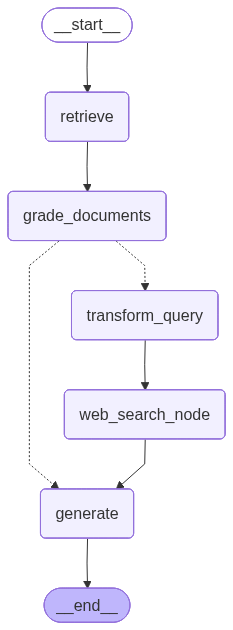

In [90]:
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image

graph = StateGraph(GraphState)

# adding the nodes

graph.add_node("retrieve",retrieve)
graph.add_node("grade_documents",grade_documents)
graph.add_node("web_search_node",web_search)
graph.add_node("transform_query",transform_query)
graph.add_node("generate",generate)

# adding the edges

graph.add_edge(START,"retrieve")
graph.add_edge("retrieve","grade_documents")
graph.add_conditional_edges("grade_documents",decide_to_generate,{"transform_query":"transform_query","generate":"generate"})
graph.add_edge("transform_query","web_search_node")
graph.add_edge("web_search_node","generate")
graph.add_edge("generate",END)

graph_builder = graph.compile()
visualization_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(visualization_graph))

In [93]:
answer = graph_builder.invoke({"question":"what is agent memory?"})
print(answer["generation"])

---RETRIEVE---
---CHECK DOCUMENTS RELEVANCE TO THE QUESTION---
---DOCUMENTS RELEVANT---
---DOCUMENTS NOT RELEVANT---
---DOCUMENTS NOT RELEVANT---
---DOCUMENTS NOT RELEVANT---
---ASSESS GEADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
Agent memory refers to the ability of an agent to store and recall information. According to the context, agents have both short-term and long-term memory. The context does not provide a detailed explanation of agent memory, but it mentions that short-term memory and long-term memory are part of the core components of agents.
